# Modelization — Predicting diseases evolution

In [2]:
import polars as pl
import numpy as np
import joblib
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "model"))  # So joblib can find data_prep

DATA_PATH = PROJECT_ROOT / "data" / "combined" / "correlation_ready.parquet"

df = pl.read_parquet(DATA_PATH)
models = joblib.load(PROJECT_ROOT / "model" / "saved" / "sk_models.joblib")

POLLUTANTS = ['bc', 'co', 'nh3', 'nmvoc', 'nox', 'oc', 'pm10', 'pm25', 'so2']
FEATURES = POLLUTANTS
# Only include diseases present in the models
DISEASE_SHORT_NAMES = {
    k: v for k, v in {
        'Cancer de la trachée, des bronches et des poumons': 'Lung Cancer',
        'Pneumoconiose': 'Pneumoconiosis',
        'Maladie pulmonaire obstructive chronique': 'COPD',
        # 'Asthme': 'Asthma',
        # 'Autres maladies respiratoires chroniques': 'Other Chronic Resp.',
    }.items() if k in models
}

print(f"Data: {df.shape[0]} rows, {df['year'].min()}-{df['year'].max()}")
print(f"Models loaded: {len(models)} diseases")

Data: 8471 rows, 1980-2022
Models loaded: 3 diseases


In [3]:
# Global emission trends (last 10 years)
global_emissions = df.group_by('year').agg([pl.col(p).mean() for p in POLLUTANTS]).sort('year')
recent = global_emissions.filter(pl.col('year') >= 2012)

first = recent.filter(pl.col('year') == recent['year'].min())
last = recent.filter(pl.col('year') == recent['year'].max())
n_years = recent['year'].max() - recent['year'].min()

growth_rates = {}
for p in POLLUTANTS:
    growth_rates[p] = ((last[p][0] / first[p][0]) ** (1/n_years) - 1) * 100
    print(f"{p:8s}: {growth_rates[p]:+.2f}%/year")

AVG_GROWTH = np.mean(list(growth_rates.values())) / 100
print(f"\nAverage: {AVG_GROWTH*100:+.2f}%/year")

bc      : -0.79%/year
co      : -0.20%/year
nh3     : +0.86%/year
nmvoc   : +0.70%/year
nox     : -0.54%/year
oc      : -0.14%/year
pm10    : -0.07%/year
pm25    : -0.31%/year
so2     : -1.27%/year

Average: -0.19%/year


In [4]:
# Scenarii: current trend + reduction targets
LATEST_YEAR = df['year'].max()
YEARS_AHEAD = 10
FUTURE_YEARS = list(range(LATEST_YEAR + 1, LATEST_YEAR + YEARS_AHEAD + 1))

current_emissions = (
    df.filter(pl.col('year') == LATEST_YEAR)
    .select(POLLUTANTS).mean()
    .with_columns([pl.col(p).log1p() for p in POLLUTANTS])
    .to_numpy().flatten()
 )

scenarios = {
    'Current trend': AVG_GROWTH,       # ~-0.2%/year
    'Reduce 5%': -0.05 / YEARS_AHEAD,  # -0.5%/year to reach -5% in 10 years
    'Reduce 10%': -0.10 / YEARS_AHEAD,
    'Reduce 15%': -0.15 / YEARS_AHEAD,
    'Reduce 20%': -0.20 / YEARS_AHEAD,
}

print(f"Base: {LATEST_YEAR}, projecting to {FUTURE_YEARS[-1]}")
for name, rate in scenarios.items():
    print(f"  {name}: {rate*100:+.2f}%/year → {(1+rate)**YEARS_AHEAD:.1%} after 10y")

Base: 2022, projecting to 2032
  Current trend: -0.19%/year → 98.1% after 10y
  Reduce 5%: -0.50%/year → 95.1% after 10y
  Reduce 10%: -1.00%/year → 90.4% after 10y
  Reduce 15%: -1.50%/year → 86.0% after 10y
  Reduce 20%: -2.00%/year → 81.7% after 10y


In [5]:
def predict_deaths(model, scaler, features):
    return model.predict(scaler.transform(features.reshape(1, -1)))[0]

results = []
for disease, m in models.items():
    short = DISEASE_SHORT_NAMES[disease]
    baseline = predict_deaths(m['model'], m['data'].scaler, current_emissions)
    results.append({'disease': short, 'scenario': 'Baseline', 'year': LATEST_YEAR, 'deaths': baseline})
    
    for scenario_name, annual_rate in scenarios.items():
        for i, year in enumerate(FUTURE_YEARS):
            mult = (1 + annual_rate) ** (i + 1)
            projected_emissions = current_emissions * mult
            deaths = predict_deaths(m['model'], m['data'].scaler, projected_emissions)
            results.append({'disease': short, 'scenario': scenario_name, 'year': year, 'deaths': deaths})

results_df = pl.DataFrame(results)
print(f"Generated {results_df.shape[0]} predictions")

Generated 153 predictions


In [6]:
print("PREDICTED DEATHS BY SCENARIO (Year 10 vs Baseline)")
print("="*65)

for disease in DISEASE_SHORT_NAMES.values():
    baseline_row = results_df.filter((pl.col('disease') == disease) & (pl.col('scenario') == 'Baseline'))
    if baseline_row.height == 0:
        print(f"\n{disease} (no baseline data)")
        continue
    baseline = baseline_row['deaths'][0]
    print(f"\n{disease} (baseline: {baseline:.1f}/100k)")
    for scenario_name in scenarios.keys():
        final_row = results_df.filter(
            (pl.col('disease') == disease) & 
            (pl.col('scenario') == scenario_name) & 
            (pl.col('year') == FUTURE_YEARS[-1])
)
        if final_row.height == 0:
            print(f"  {scenario_name:15s}: (no data)")
            continue
        final = final_row['deaths'][0]
        change = ((final - baseline) / baseline) * 100
        print(f"  {scenario_name:15s}: {final:.1f}/100k ({change:+.1f}%)")

PREDICTED DEATHS BY SCENARIO (Year 10 vs Baseline)

Lung Cancer (baseline: 19.2/100k)
  Current trend  : 20.7/100k (+7.7%)
  Reduce 5%      : 18.4/100k (-4.1%)
  Reduce 10%     : 18.2/100k (-5.3%)
  Reduce 15%     : 18.6/100k (-3.0%)
  Reduce 20%     : 27.3/100k (+42.4%)

Pneumoconiosis (baseline: 0.2/100k)
  Current trend  : 0.3/100k (+13.7%)
  Reduce 5%      : 0.3/100k (+36.4%)
  Reduce 10%     : 0.4/100k (+59.2%)
  Reduce 15%     : 0.0/100k (-86.9%)
  Reduce 20%     : 0.1/100k (-69.8%)

COPD (baseline: 30.5/100k)
  Current trend  : 45.4/100k (+49.0%)
  Reduce 5%      : 28.8/100k (-5.5%)
  Reduce 10%     : 20.4/100k (-33.2%)
  Reduce 15%     : 28.3/100k (-7.3%)
  Reduce 20%     : 26.1/100k (-14.4%)


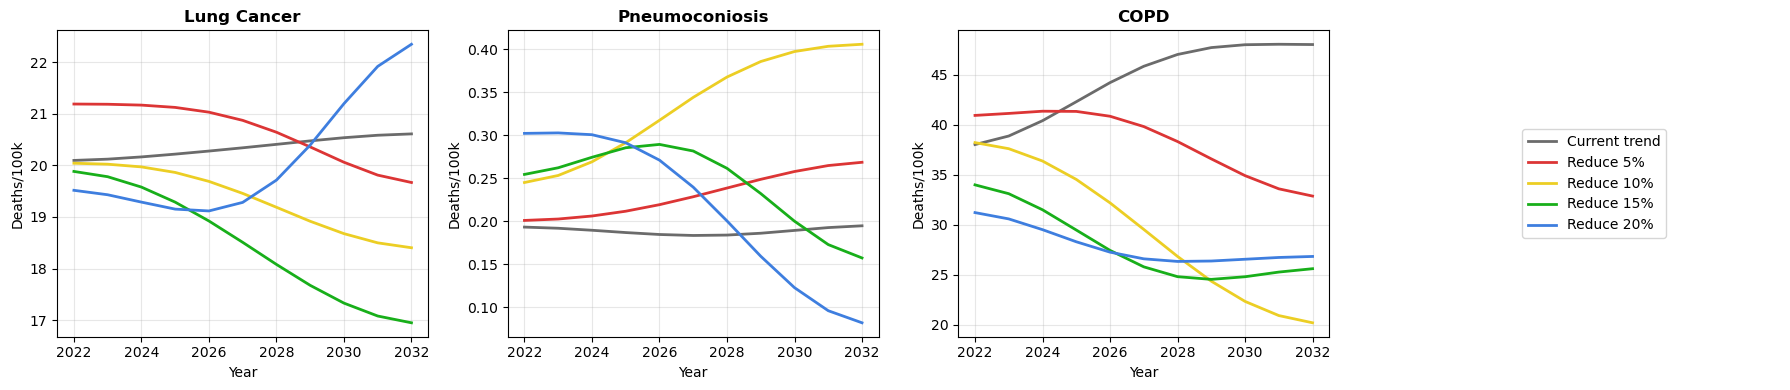

In [8]:
# Plot with smoothed curves
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
axes = axes.flatten()
colors = {'Current trend': "#6b6b6b", 'Reduce 5%': "#dc3535", 'Reduce 10%': "#ecce24", 
          'Reduce 15%': "#18af1a", 'Reduce 20%': "#3e7edf"}

for idx, disease in enumerate(DISEASE_SHORT_NAMES.values()):
    ax = axes[idx]
    baseline_row = results_df.filter((pl.col('disease') == disease) & (pl.col('scenario') == 'Baseline'))
    if baseline_row.height == 0:
        continue
    baseline = baseline_row['deaths'][0]
    for scenario_name, color in colors.items():
        data = results_df.filter((pl.col('disease') == disease) & (pl.col('scenario') == scenario_name)).sort('year')
        if data.height == 0:
            continue
        years = [LATEST_YEAR] + data['year'].to_list()
        deaths = [baseline] + data['deaths'].to_list()
        deaths_smooth = gaussian_filter1d(deaths, sigma=3)
        ax.plot(years, deaths_smooth, color=color, lw=2, label=scenario_name)
    ax.set_title(disease, fontweight='bold')
    ax.set_xlabel('Year')
    ax.set_ylabel('Deaths/100k')
    ax.grid(True, alpha=0.3)
axes[-1].axis('off')
axes[-1].legend(*axes[0].get_legend_handles_labels(), loc='center', fontsize=10)
plt.tight_layout()
plt.show()

## Scenario analysis with PyTorch MLP model
Let's repeat the scenario analysis using the PyTorch MLP model (linear layers) for comparison.

In [125]:
# Load exported PyTorch models and scalers
import torch
import joblib
from pt_model import MLP

pt_savedir = PROJECT_ROOT / "model" / "saved"
pytorch_models = {}
pytorch_scalers = {}
for disease, short in DISEASE_SHORT_NAMES.items():
    model_path = pt_savedir / f"pt_{short.replace(' ', '_').lower()}.pt"
    scaler_path = pt_savedir / f"pt_{short.replace(' ', '_').lower()}_scaler.joblib"
    if not model_path.exists() or not scaler_path.exists():
        continue
    scaler = joblib.load(scaler_path)
    n_features = len(POLLUTANTS)
    model = MLP(n_features)
    model.load_state_dict(torch.load(model_path, map_location="cpu"))
    model.eval()
    pytorch_models[disease] = model
    pytorch_scalers[disease] = scaler
print("Loaded exported PyTorch models and scalers.")

Loaded exported PyTorch models and scalers.


In [126]:
# Scenario projection with exported PyTorch models
def predict_deaths_torch(model, scaler, features):
    features = scaler.transform(features.reshape(1, -1))
    features_tensor = torch.FloatTensor(features)
    with torch.no_grad():
        pred = model(features_tensor).item()
    return pred

results_pt = []
for disease, model in pytorch_models.items():
    scaler = pytorch_scalers[disease]
    short = DISEASE_SHORT_NAMES[disease]
    baseline = predict_deaths_torch(model, scaler, current_emissions)
    results_pt.append({'disease': short, 'scenario': 'Baseline', 'year': LATEST_YEAR, 'deaths': baseline})
    for scenario_name, annual_rate in scenarios.items():
        for i, year in enumerate(FUTURE_YEARS):
            mult = (1 + annual_rate) ** (i + 1)
            projected_emissions = current_emissions * mult
            deaths = predict_deaths_torch(model, scaler, projected_emissions)
            results_pt.append({'disease': short, 'scenario': scenario_name, 'year': year, 'deaths': deaths})
results_pt_df = pl.DataFrame(results_pt)
print(f"Generated {results_pt_df.shape[0]} PyTorch predictions (exported models)")

Generated 153 PyTorch predictions (exported models)


In [127]:
# Summary table for PyTorch
print("PREDICTED DEATHS BY SCENARIO (PyTorch, Year 10 vs Baseline)")
print("="*65)
for disease in DISEASE_SHORT_NAMES.values():
    baseline_row = results_pt_df.filter((pl.col('disease') == disease) & (pl.col('scenario') == 'Baseline'))
    if baseline_row.height == 0:
        print(f"\n{disease} (no baseline data)")
        continue
    baseline = baseline_row['deaths'][0]
    print(f"\n{disease} (baseline: {baseline:.1f}/100k)")
    for scenario_name in scenarios.keys():
        final_row = results_pt_df.filter(
            (pl.col('disease') == disease) & 
            (pl.col('scenario') == scenario_name) & 
            (pl.col('year') == FUTURE_YEARS[-1])
)
        if final_row.height == 0:
            print(f"  {scenario_name:15s}: (no data)")
            continue
        final = final_row['deaths'][0]
        change = ((final - baseline) / baseline) * 100
        print(f"  {scenario_name:15s}: {final:.1f}/100k ({change:+.1f}%)")

PREDICTED DEATHS BY SCENARIO (PyTorch, Year 10 vs Baseline)

Lung Cancer (baseline: 26.9/100k)
  Current trend  : 26.4/100k (-1.9%)
  Reduce 5%      : 25.6/100k (-4.9%)
  Reduce 10%     : 21.2/100k (-21.1%)
  Reduce 15%     : 18.1/100k (-32.6%)
  Reduce 20%     : 16.9/100k (-37.3%)

Pneumoconiosis (baseline: 0.2/100k)
  Current trend  : 0.3/100k (+26.6%)
  Reduce 5%      : 0.3/100k (+54.2%)
  Reduce 10%     : 0.2/100k (+16.9%)
  Reduce 15%     : 0.1/100k (-48.1%)
  Reduce 20%     : -0.0/100k (-103.1%)

COPD (baseline: 35.7/100k)
  Current trend  : 37.7/100k (+5.6%)
  Reduce 5%      : 33.7/100k (-5.6%)
  Reduce 10%     : 27.1/100k (-24.2%)
  Reduce 15%     : 24.3/100k (-32.0%)
  Reduce 20%     : 27.4/100k (-23.3%)


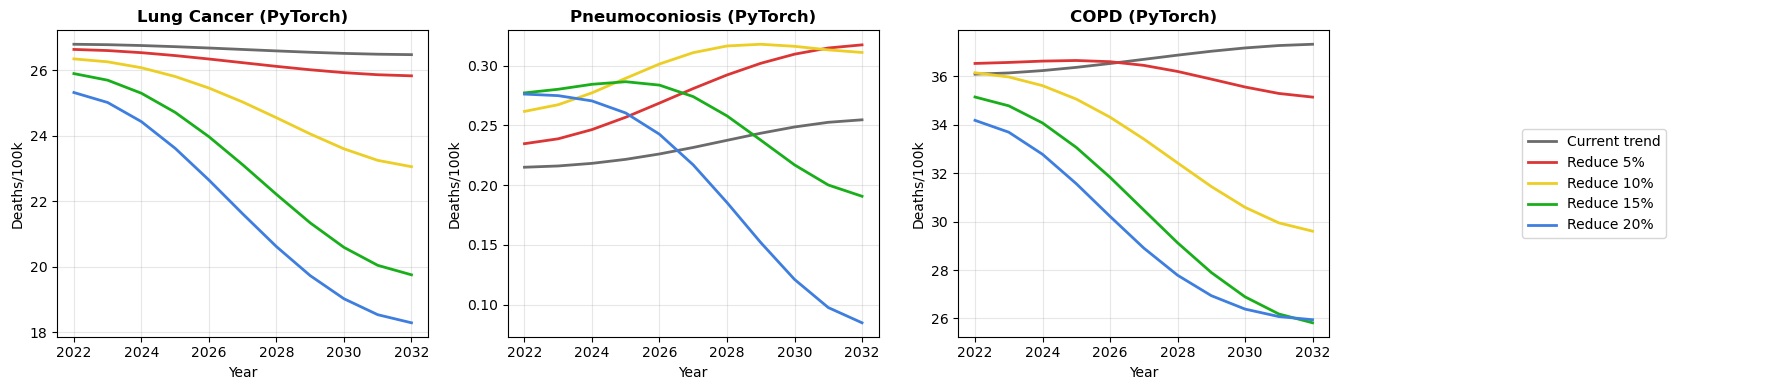

In [135]:
# Plot with smoothed curves (PyTorch)
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
axes = axes.flatten()
colors = {'Current trend': "#6b6b6b", 'Reduce 5%': "#dc3535", 'Reduce 10%': "#ecce24", 
          'Reduce 15%': "#18af1a", 'Reduce 20%': "#3e7edf"}

for idx, disease in enumerate(DISEASE_SHORT_NAMES.values()):
    ax = axes[idx]
    baseline_row = results_pt_df.filter((pl.col('disease') == disease) & (pl.col('scenario') == 'Baseline'))
    if baseline_row.height == 0:
        continue
    baseline = baseline_row['deaths'][0]
    for scenario_name, color in colors.items():
        data = results_pt_df.filter((pl.col('disease') == disease) & (pl.col('scenario') == scenario_name)).sort('year')
        if data.height == 0:
            continue
        years = [LATEST_YEAR] + data['year'].to_list()
        deaths = [baseline] + data['deaths'].to_list()
        deaths_smooth = gaussian_filter1d(deaths, sigma=3)
        ax.plot(years, deaths_smooth, color=color, lw=2, label=scenario_name)
    ax.set_title(disease + " (PyTorch)", fontweight='bold')
    ax.set_xlabel('Year')
    ax.set_ylabel('Deaths/100k')
    ax.grid(True, alpha=0.3)
axes[-1].axis('off')
axes[-1].legend(*axes[0].get_legend_handles_labels(), loc='center', fontsize=10)
plt.tight_layout()
plt.show()

Note : Le modèle en arbre de sklearn n'est pas bon pour extrapoler, notre réseau de neurones lui a une moins bonne précision mais est bien meilleur en extrapolation